In [1]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy import stats
from scipy.sparse import issparse
import sys 

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/2025_mouse_longread/2025_mouse_collapse_GRCm38/all_samples_sp_collapse_all_chr_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"

# Load the database
db_mouse = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


## To-do
- remove unused functions
- make sure junctions and cells are reindexed in .obs and .var so correctly pulled from psi layer 
- coordination, be more careful about getting mean J1 and mean J2, use just non zero values for these calcualtions and record how many
because otherwise mean gets crazy skewed
- go through one sanity check example showing raw data counts and psi values for J1 in young vs J1 in old, partner J2 should show opposite effect

In [2]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/preprocessed_data_20251019.h5ad"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
full_atse_map = pd.read_csv(ATSE_FILE_PATH, sep="\t")

print("Loading data...")
splice_adata = ad.read_h5ad(SPLICE_INPUT)
print(f"Loaded {splice_adata.n_obs:,} cells and {splice_adata.n_vars:,} junctions")

output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs"
# make output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# load all ATSEs for coordination analysis 
all_juncs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/junction_df_all_20251020.csv"
all_atses = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/atse_df_all_20251020.csv"
all_juncs_df = pd.read_csv(all_juncs)
all_atses_df = pd.read_csv(all_atses)
all_juncs_df.head()
all_atses_df.head()


PART 1: DATA LOADING AND PREPROCESSING


Loading data...
Loaded 85,692 cells and 52,290 junctions


,cell_type,event_id,n_junctions,mean_delta_mean,median_delta_median,mean_abs_delta,std_delta,sign_concordance,mean_delta_pb,median_delta_pb,opposite_sign_pair
0,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_1,2,-1.387779e-17,0.000000,0.004092,0.005787,0.500000,1.040834e-17,1.040834e-17,1.0
1,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_2,3,2.775558e-17,-0.006706,0.022149,0.029925,0.666667,9.251859e-18,1.517588e-02,NaN
2,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_2,2,-2.775558e-17,0.000000,0.142857,0.202031,0.500000,-1.387779e-17,-1.387779e-17,1.0
3,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_1,4,0.000000e+00,0.000000,0.107143,0.163684,0.750000,-2.775558e-17,7.836134e-02,NaN
4,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019971.10_atse_1,3,9.251859e-18,0.000000,0.047619,0.071429,0.500000,-1.850372e-17,0.000000e+00,NaN


In [3]:
output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs"
# make output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [4]:
def extract_junction_data(adata, junction_ids, cell_type, groupby_col='tissue_celltype'):
    """
    Extract junction counts, ATSE counts, and PSI values for given junctions and cell type.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object with junction data
    junction_ids : str or list
        Single junction ID or list of junction IDs to extract
    cell_type : str
        Cell type to filter for (value in groupby_col)
    groupby_col : str, default='tissue_celltype'
        Column name to use for cell type filtering
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: cell_id, junction_id, junction_counts, atse_counts, psi_value
    """
    
    # Ensure junction_ids is a list
    if isinstance(junction_ids, str):
        junction_ids = [junction_ids]
    
    # Filter cells for the specified cell type
    if groupby_col not in adata.obs.columns:
        raise ValueError(f"Column '{groupby_col}' not found in adata.obs")
    
    cell_mask = adata.obs[groupby_col] == cell_type
    if not cell_mask.any():
        raise ValueError(f"No cells found for cell type '{cell_type}'")
        
    # Find ATSE that junction belongs to via event_id 
    atse_event_id = adata.var[adata.var["junction_id"].isin(junction_ids)]["event_id"].unique()[0]

    # Find all junctions in this ATSE event
    atse_junctions = adata.var[adata.var['event_id'] == atse_event_id]['junction_id']
    junction_mask = adata.var['junction_id'].isin(atse_junctions)

    # Get the relevant matrices
    junction_matrix = adata.layers["cell_by_junction_matrix"]
    atse_matrix = adata.layers["cell_by_cluster_matrix"] 
    psi_matrix = adata.layers["psi"]
    
    # Extract data for selected cells and junctions
    cell_indices = np.where(cell_mask)[0]
    junction_indices = np.where(junction_mask)[0]
    
    results = []
    
    for cell_idx in cell_indices:
        cell_id = adata.obs.index[cell_idx]
        cell_age_group = adata.obs.loc[cell_id, "age_group"]
        
        for junc_idx in junction_indices:
            # Get junction ID
            if 'junction_id' in adata.var.columns:
                junction_id = adata.var.iloc[junc_idx]['junction_id']
            else:
                junction_id = adata.var.index[junc_idx]
            
            # Extract values (handle sparse matrices)
            if issparse(junction_matrix):
                junction_count = junction_matrix[cell_idx, junc_idx]
                atse_count = atse_matrix[cell_idx, junc_idx]
                psi_value = psi_matrix[cell_idx, junc_idx]
            else:
                junction_count = junction_matrix[cell_idx, junc_idx]
                atse_count = atse_matrix[cell_idx, junc_idx]
                psi_value = psi_matrix[cell_idx, junc_idx]
            
            # Only include non-zero entries (sparse data)
            if junction_count > 0 or atse_count > 0:
                results.append({
                    'cell_id': cell_id,
                    'cell_age_group': cell_age_group,
                    'junction_id': junction_id,
                    'junction_counts': float(junction_count),
                    'atse_counts': float(atse_count),
                    'psi_value': float(psi_value) if not np.isnan(psi_value) else None
                })
    
    df = pd.DataFrame(results)
    
    gene_name = adata.var[adata.var["junction_id"].isin(junction_ids)]["gene_name"].unique()[0]
    df["event_id"] = atse_event_id
    df["cell_type"] = cell_type
    df["gene_name"] = gene_name
    return df

def delta_psi_from_result_df(result_df, young_label="young", old_label="old", cell_type=None):
    """
    Compute per-junction ΔPSI (old - young), pseudobulk per age group,
    and ATSE-level coordination from a tidy `result_df` produced by `extract_junction_data`.

    Required columns in `result_df`:
      ['cell_id','cell_age_gr oup','junction_id','psi_value',
       'junction_counts','atse_counts','event_id']
    Optional: ['gene_name']

    Parameters
    ----------
    result_df : pd.DataFrame
    young_label, old_label : str
        Labels used in `cell_age_group` for young/old.
    cell_type : str or None
        The cell type the `result_df` was filtered to (will be attached to outputs).
        If None, defaults to 'unknown'.

    Returns
    -------
    junction_df : DataFrame with columns
        ['cell_type','junction_id','event_id','gene_name'(opt),
         'n_cells_young','n_cells_old',
         'psi_mean_young','psi_mean_old','delta_psi_mean',
         'psi_median_young','psi_median_old','delta_psi_median',
         'pb_young','pb_old','delta_pb']
    atse_df : DataFrame with columns
        ['cell_type','event_id','n_junctions','mean_delta_mean','median_delta_median',
         'mean_abs_delta','std_delta','sign_concordance','opposite_sign_pair']
    """

    req = {"cell_id","cell_age_group","junction_id","psi_value",
           "junction_counts","atse_counts","event_id"}
    missing = req - set(result_df.columns)
    if missing:
        raise ValueError(f"result_df missing required columns: {sorted(missing)}")

    df = result_df.copy()
    cell_type = result_df["cell_type"].iloc[0]

    # --- Per-junction per-age PSI stats (mean/median, counts) ---
    agg = (df.groupby(["junction_id","cell_age_group"], observed=True)
             .agg(psi_mean=("psi_value","mean"),
                  psi_median=("psi_value","median"),
                  n_cells=("psi_value","count")))
    wide = agg.unstack("cell_age_group")

    def getcol(name, age):
        col = (name, age)
        return wide[col] if col in wide.columns else pd.Series(index=wide.index, dtype=float)

    psi_mean_y = getcol("psi_mean", young_label)
    psi_mean_o = getcol("psi_mean", old_label)
    psi_med_y  = getcol("psi_median", young_label)
    psi_med_o  = getcol("psi_median", old_label)
    n_y        = getcol("n_cells", young_label).astype("Int64")
    n_o        = getcol("n_cells", old_label).astype("Int64")

    d_mean = psi_mean_o - psi_mean_y
    d_med  = psi_med_o  - psi_med_y

    # --- Pseudobulk per junction-age: sum(junc)/sum(atse) ---
    sums = (df.groupby(["junction_id","cell_age_group"], observed=True)
              .agg(junc_sum=("junction_counts","sum"),
                   atse_sum=("atse_counts","sum"))).unstack("cell_age_group")

    def getsum(name, age):
        col = (name, age)
        return sums[col] if col in sums.columns else pd.Series(index=sums.index, dtype=float)

    junc_sum_y = getsum("junc_sum", young_label)
    junc_sum_o = getsum("junc_sum", old_label)
    atse_sum_y = getsum("atse_sum", young_label)
    atse_sum_o = getsum("atse_sum", old_label)

    def safe_div(num, den):
        num = num.astype(float); den = den.astype(float)
        return np.divide(num, den, out=np.full_like(num, np.nan, dtype=float), where=(den > 0))

    pb_y = safe_div(junc_sum_y, atse_sum_y)
    pb_o = safe_div(junc_sum_o, atse_sum_o)
    d_pb = pb_o - pb_y

    # --- Junction-level table (keep junction_id as a normal column) ---
    j_meta = df.drop_duplicates("junction_id").set_index("junction_id")
    junction_df = pd.DataFrame({
        "event_id": j_meta["event_id"],
    })
    if "gene_name" in j_meta.columns:
        junction_df["gene_name"] = j_meta["gene_name"]

    junction_df["n_cells_young"]     = n_y
    junction_df["n_cells_old"]       = n_o
    junction_df["psi_mean_young"]    = psi_mean_y
    junction_df["psi_mean_old"]      = psi_mean_o
    junction_df["delta_psi_mean"]    = d_mean
    junction_df["psi_median_young"]  = psi_med_y
    junction_df["psi_median_old"]    = psi_med_o
    junction_df["delta_psi_median"]  = d_med
    junction_df["pb_young"]          = pb_y
    junction_df["pb_old"]            = pb_o
    junction_df["delta_pb"]          = d_pb

    # move junction_id out of index into a column, and add cell_type
    junction_df = junction_df.reset_index()  # adds 'junction_id' column
    junction_df.insert(0, "cell_type", cell_type)

    # reorder columns exactly as requested (gene_name optional)
    base_cols = [
        "cell_type", "junction_id", "event_id",
        "gene_name" if "gene_name" in junction_df.columns else None,
        "n_cells_young","n_cells_old",
        "psi_mean_young","psi_mean_old","delta_psi_mean",
        "psi_median_young","psi_median_old","delta_psi_median",
        "pb_young","pb_old","delta_pb",
    ]
    junction_df = junction_df[[c for c in base_cols if c is not None]]

    # --- ATSE-level summaries (also tag cell_type) ---
    def sign_concordance(series):
        s = np.sign(series.to_numpy(dtype=float))
        nz = s[s != 0]
        if nz.size == 0:
            return np.nan
        p_pos = (nz > 0).mean()
        return max(p_pos, 1.0 - p_pos)

    def opposite_sign_pair(series):
        s = np.sign(series.to_numpy(dtype=float))
        if s.size != 2:
            return np.nan
        return bool(np.array_equal(np.sort(s), np.array([-1.0, 1.0])))

    atse_df = (junction_df
               .groupby("event_id", observed=True)
               .agg(n_junctions=("junction_id","count"),
                    mean_delta_mean=("delta_psi_mean","mean"),
                    median_delta_median=("delta_psi_median","median"),
                    mean_abs_delta=("delta_psi_mean", lambda x: float(np.mean(np.abs(x)))),
                    std_delta=("delta_psi_mean","std"),
                    sign_concordance=("delta_psi_mean", sign_concordance),
                    # get also mean delta_pb and median delta_pb
                    mean_delta_pb=("delta_pb","mean"),
                    median_delta_pb=("delta_pb","median"),
                    opposite_sign_pair=("delta_psi_mean", opposite_sign_pair))
               .reset_index())
    atse_df.insert(0, "cell_type", cell_type)

    # final column order
    atse_df = atse_df[[
        "cell_type","event_id","n_junctions","mean_delta_mean",
        "median_delta_median","mean_abs_delta","std_delta",
        "sign_concordance","opposite_sign_pair",
        "mean_delta_pb","median_delta_pb"
    ]]

    return junction_df, atse_df

def plot_junction_usage_by_age(result_df, output_dir, colors={'young': 'purple', 'old': 'green'}):
    """
    Plot junction usage by age group with violin plots and mean single cell PSI values
    """
    
    # Order to old is always plotted first then young
    # Make cell_age_group a categorical variable
    result_df['cell_age_group'] = pd.Categorical(result_df['cell_age_group'], categories=['old', 'young'], ordered=True)
    
    # Calculate pseudobulk values (for reporting)
    pseudobulk = result_df.groupby(['junction_id', 'cell_age_group']).agg({
        'junction_counts': 'sum',
        'atse_counts': 'sum'
    }).reset_index()
    pseudobulk['pseudobulk_psi'] = pseudobulk['junction_counts'] / pseudobulk['atse_counts']
    
    # Calculate mean single cell PSI values (for plotting triangles)
    mean_psi = result_df.groupby(['junction_id', 'cell_age_group']).agg({
        'psi_value': 'mean'
    }).reset_index()
    mean_psi.rename(columns={'psi_value': 'mean_sc_psi'}, inplace=True)
    
    # Merge pseudobulk and mean PSI data
    combined_stats = pseudobulk.merge(mean_psi, on=['junction_id', 'cell_age_group'])
    
    # Get gene name and cell type for title
    gene_name = result_df['gene_name'].iloc[0]
    cell_type = result_df['cell_type'].iloc[0]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Violin plot (swapped x and y)
    sns.violinplot(data=result_df, y='junction_id', x='psi_value', hue='cell_age_group',
                   ax=ax, palette=colors, inner=None, cut=0, orient='h')
    
    # Jitter plot
    sns.stripplot(data=result_df, y='junction_id', x='psi_value', hue='cell_age_group',
                  dodge=True, alpha=0.4, size=2, ax=ax, legend=False, palette='grey', orient='h')
    
    # Add mean single cell PSI markers (triangles show mean, not pseudobulk)
    # Get the junction list in the order they appear in the plot
    junction_order = result_df['junction_id'].unique()
    
    # Define the categorical order (matching what you set earlier)
    age_categories = ['old', 'young']
    
    for idx, row in combined_stats.iterrows():
        junction_idx = list(junction_order).index(row['junction_id'])
        
        # Use the categorical order to determine position
        # 'old' will be at position 0, 'young' at position 1
        age_idx = age_categories.index(row['cell_age_group'])
        
        # Calculate y_offset based on the categorical position
        # For 2 groups: old gets -0.2, young gets +0.2
        n_groups = len(age_categories)
        y_offset = (age_idx - (n_groups - 1) / 2) * 0.4 / n_groups * 2
        
        ax.scatter(row['mean_sc_psi'], junction_idx + y_offset,
                   marker='^', s=100, color='black', zorder=10, edgecolors='white', linewidths=1.5)
    
    # Add sample counts
    counts = result_df.groupby(['junction_id', 'cell_age_group']).size().reset_index(name='n')
    print(f"\n{gene_name} - {cell_type}")
    print("\nSample counts per junction and age group:")
    print(counts.pivot(index='junction_id', columns='cell_age_group', values='n'))
    
    # Print comparison of pseudobulk vs mean single cell PSI
    print("\nPseudoBulk PSI vs Mean Single Cell PSI comparison:")
    comparison = combined_stats[['junction_id', 'cell_age_group', 'pseudobulk_psi', 'mean_sc_psi']].copy()
    comparison['difference'] = comparison['pseudobulk_psi'] - comparison['mean_sc_psi']
    print(comparison.round(4))
    
    ax.set_xlabel('PSI Value', fontsize=12)
    ax.set_ylabel('Junction ID', fontsize=12)
    ax.set_title(f'{gene_name} - {cell_type}\n(Triangles show mean single cell PSI)', fontsize=14, fontweight='bold')
    ax.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add line at psi of 0.5 
    # ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    # Save figure as PDF in output directory
    plt.savefig(f"{output_dir}/{gene_name}_{cell_type}_junction_usage.pdf", 
                bbox_inches='tight', dpi=300)
    plt.show()
    
    return combined_stats

In [5]:
example_df = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/intermediate/junction_Aorta_Endothelial_cell.csv" 
example_df = pd.read_csv(example_df)
example_df.sort_values(by="delta_psi_mean", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
288,Aorta_Endothelial cell,chr10_127167542_127167700_+,ENSMUSG00000006731.10_atse_3,B4GALNT1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.000000,1.0,1.0
11053,Aorta_Endothelial cell,chr15_102207920_102208235_+,ENSMUSG00000046897.17_atse_2,ZFP740,2.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.000000,1.0,1.0
38261,Aorta_Endothelial cell,chr7_4010632_4010729_-,ENSMUSG00000055541.17_atse_1,LAIR1,2.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.000000,1.0,1.0
63,Aorta_Endothelial cell,chr10_11149503_11151612_+,ENSMUSG00000090112.8_atse_1,SHPRH,7.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.000000,1.0,1.0
335,Aorta_Endothelial cell,chr10_127283162_127283391_-,ENSMUSG00000025409.14_atse_5,MBD6,2.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.000000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46022,Aorta_Endothelial cell,chrX_96571024_96573567_+,ENSMUSG00000031209.14_atse_3,HEPH,2.0,NaN,0.5,NaN,NaN,0.5,NaN,NaN,0.995283,NaN,NaN
46023,Aorta_Endothelial cell,chrX_96571024_96573570_+,ENSMUSG00000031209.14_atse_3,HEPH,2.0,NaN,0.5,NaN,NaN,0.5,NaN,NaN,0.004717,NaN,NaN
46024,Aorta_Endothelial cell,chrX_98563680_98564291_-,ENSMUSG00000031214.13_atse_2,OPHN1,NaN,2.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
46025,Aorta_Endothelial cell,chrX_98563680_98564715_-,ENSMUSG00000031214.13_atse_2,OPHN1,NaN,2.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN


### Print ATSE isoform plot

In [6]:
splice_adata.var["gene_name"].nunique()

7409

Unique transcripts: {'ENSMUST00000234507.1', 's45b07301949893b9:edc872739d88eb3c6', 'sb5b8f2efeb9298e4:e2a975b536a2e17e9', 'sa99a8f5f6cd7c65d:e2e7e926204970628', 's2ba96cdde3d2d767:e72786b2ac6a59be0', 's6bd3a03acb72485b:ec7363fb4cf458f2c', 's0fdc8e4822e854b7:e2e7e926204970628', 's671eeb8e9e0d7214:edb6953c13d446f5a', 's6bd3a03acb72485b:ebbe9d040898eb412', 's7dc68bcf889f05d0:edb6953c13d446f5a', 's0afd2f13b485400a:ef5fa0581e47eb114', 'se30b45edd8e2c287:edac179d22848acde', 'se915f0da8bcdfcdc:e37f806c7f57e5199', 's12eb36baf3aa2b04:e37f806c7f57e5199', 's4a6299085f5434b7:ebbe9d040898eb412', 's6bd3a03acb72485b:e8ab14c0e5796c2ee', 'saa92723669bb4a2f:ecdf340a60f7ac5aa', 's50d70ee797d25804:ef5fa0581e47eb114', 's4a6299085f5434b7:e8ab14c0e5796c2ee', 's3f1edcb1bdea8ca5:e1c5c633268823b21', 'saa92723669bb4a2f:e2c52a02ba4b1874e', 's1f0c3e8823ef7ca1:edc872739d88eb3c6', 'sc261e2109b2a15ab:e60ffc61cc2228869', 's4a6299085f5434b7:edac179d22848acde', 's0e8dd15c7c6cb0c2:e0f4d147f36471977', 'sf6e4ff98bf1806bb:

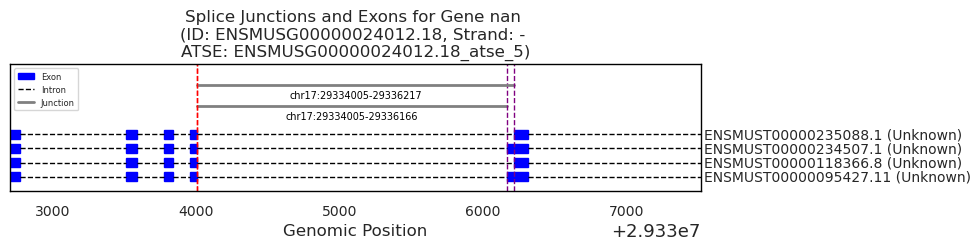

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/200746_mouse_nan_ENSMUSG00000024012.18_atse_5.pdf


{'junctions':                            event_id                gene_id  gene_name  \
 13034  ENSMUSG00000024012.18_atse_5  ENSMUSG00000024012.18        NaN   
 13035  ENSMUSG00000024012.18_atse_5  ENSMUSG00000024012.18        NaN   
 
        gene_types  num_junctions           event_type chromosome strand  \
 13034         NaN              2  alternative_5_prime      chr17      -   
 13035         NaN              2  alternative_5_prime      chr17      -   
 
        atse_start  atse_end  ...  acceptor_usage  donor_total_reads  \
 13034    29334005  29336217  ...          0.9996            5291913   
 13035    29334005  29336217  ...          0.4943            2616258   
 
        acceptor_total_reads  splice_motif  donor_seq  acceptor_seq  \
 13034               2674160         GT-AG         GT            AG   
 13035               5291913         GT-AG         GT            AG   
 
       position_off_5_prime position_off_3_prime usage_ratio  \
 13034                  1.0         

In [7]:
mouse_event = "ENSMUSG00000024012.18_atse_5"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, full_atse_map, db_mouse,
                 species="mouse", base_width=10, 
                       trans_height=0.4, output_dir=output_dir,
                  padding=300, show_junc_lines=True)

### Look at coordination (sanity check, when one goes up the other should go down in activity)

In [8]:
twos = splice_adata.var[splice_adata.var["num_junctions"] == 2]
twos_events = twos["event_id"].unique()
# keep only rows where n_cells_young and n_cells_old is greater than 50    
all_juncs_df = all_juncs_df[all_juncs_df["n_cells_young"] > 50]
all_juncs_df = all_juncs_df[all_juncs_df["n_cells_old"] > 50]
twos_all_juncs = all_juncs_df[all_juncs_df["event_id"].isin(twos_events)]

# subset twos_all_juncs to only those where absolute delta_psi_mean is greater than 0.05 
twos_all_juncs = twos_all_juncs[twos_all_juncs["delta_psi_mean"].abs() > 0.05]

# Group by cell_type and event_id, then calculate coordination metrics
coordination = twos_all_juncs.groupby(['cell_type', 'event_id']).agg({
    'delta_psi_mean': lambda x: x.std() if len(x) > 1 else 0,  # Spread of changes
    'junction_id': 'count'  # Number of junctions
}).rename(columns={'junction_id': 'n_junctions', 'delta_psi_mean': 'delta_psi_std'})

# Add coordination score: high std = strong coordination (opposite directions)
coordination['coordination_strength'] = coordination['delta_psi_std']

# Filter for events with multiple junctions (where coordination matters)
coordination = coordination[coordination['n_junctions'] > 1]
coordination.sort_values('coordination_strength', ascending=False).head(10)

,,delta_psi_std,n_junctions,coordination_strength
cell_type,event_id,,,
Diaphragm_Skeletal muscle cell,ENSMUSG00000027962.14_atse_2,0.627259,2,0.627259
Bladder_Urogenital epithelial cell,ENSMUSG00000020232.17_atse_1,0.475089,2,0.475089
Large_Intestine_Intestinal epithelial cell,ENSMUSG00000020232.17_atse_1,0.453597,2,0.453597
Bladder_Bladder epithelial cell,ENSMUSG00000032010.15_atse_2,0.432649,2,0.432649
GAT_Mesenchymal stem cell,ENSMUSG00000008734.9_atse_1,0.408366,2,0.408366
Large_Intestine_Epithelial stem cell,ENSMUSG00000043085.14_atse_1,0.398347,2,0.398347
Heart_Endothelial cell,ENSMUSG00000056050.13_atse_1,0.391034,2,0.391034
Brain_Non-Myeloid_Other neuron,ENSMUSG00000027940.18_atse_7,0.382835,2,0.382835
Large_Intestine_Intestinal epithelial cell,ENSMUSG00000038172.14_atse_3,0.373841,2,0.373841


### Panel C -> show delta junction usage ratio in older versus younger cells 

In [9]:
# Plot delta PSI by cell type with junction counts
# Order cell types by total number of junctions with absolute delta PSI > 0.05
ct_order = all_juncs_df.groupby('cell_type')['delta_psi_mean'].apply(
    lambda x: (abs(x) > 0.05).sum()
).sort_values().index

Figure saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/delta_psi_by_celltype_ATSEmax_with_counts.pdf


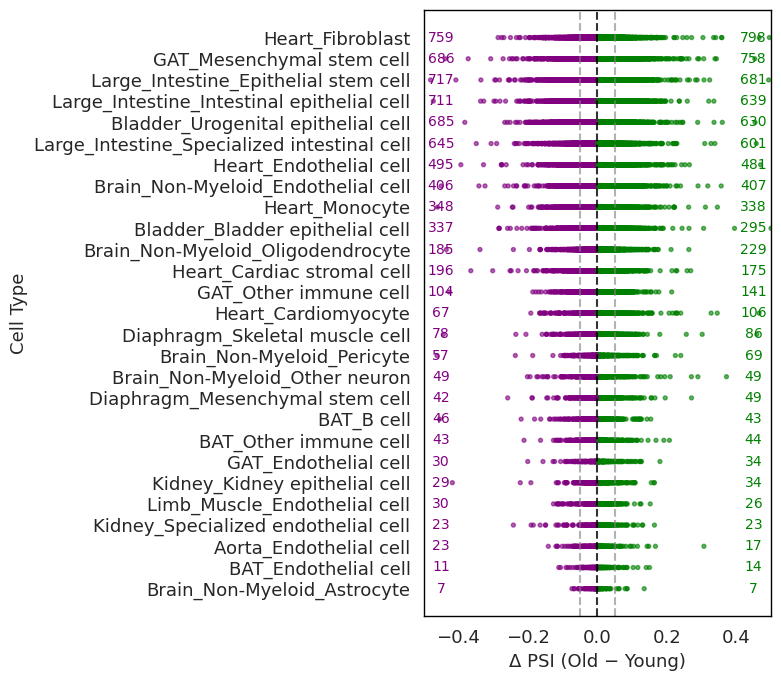

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Reduce to one row per (cell_type, event_id): junction with max |ΔPSI| ---
idx = (
    all_juncs_df
    .groupby(['cell_type','event_id'])['delta_psi_mean']
    .apply(lambda s: s.abs().idxmax())
)
reduced = all_juncs_df.loc[idx.values].reset_index(drop=True)

# --- Order cell types by # of events with |ΔPSI| > 0.05 (ascending) ---
ct_order = (
    reduced
    .assign(big = (reduced['delta_psi_mean'].abs() > 0.05))
    .groupby('cell_type')['big'].sum()
    .sort_values()
    .index
)
ct_to_y = {ct:i for i, ct in enumerate(ct_order)}

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))
colors = np.where(reduced['delta_psi_mean'] < 0, 'purple', 'green')

ax.scatter(
    reduced['delta_psi_mean'].to_numpy(),
    reduced['cell_type'].map(ct_to_y).to_numpy(),
    c=colors, alpha=0.6, s=8, rasterized=True
)

# Reference lines and limits
ax.axvline(0.0, color='black', linestyle='--', alpha=0.8)
ax.axvline(0.05, color='grey', linestyle='--', alpha=0.6)
ax.axvline(-0.05, color='grey', linestyle='--', alpha=0.6)
ax.set_xlim(-0.5, 0.5)  # keeps the side counts neatly inside the plot

# Labels
ax.set_xlabel('Δ PSI (Old − Young)')
ax.set_ylabel('Cell Type')
ax.set_yticks(range(len(ct_order)))
ax.set_yticklabels(ct_order)

# --- Add junction/event counts per side (use the reduced table) ---
for i, ct in enumerate(ct_order):
    ct_data = reduced[reduced['cell_type'] == ct]
    high_count = (ct_data['delta_psi_mean'] > 0.05).sum()
    low_count  = (ct_data['delta_psi_mean'] < -0.05).sum()
    ax.text( 0.45, i, f'{high_count}', ha='center', va='center',
             fontsize=10, color='green')
    ax.text(-0.45, i, f'{low_count}',  ha='center', va='center',
             fontsize=10, color='purple')

plt.tight_layout()

# Save
output_file = os.path.join(output_dir, "delta_psi_by_celltype_ATSEmax_with_counts.pdf")
plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_file}")

plt.show()

In [11]:
all_juncs_df.sort_values(by="delta_psi_mean")

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
438421,Brain_Non-Myeloid_Other neuron,chrX_166384000_166386951_+,ENSMUSG00000031342.17_atse_3,GPM6B,87.0,101.0,0.568072,0.059673,-0.508398,0.883495,0.000000,-0.883495,0.136331,0.004192,-0.132138
199690,Heart_Cardiac stromal cell,chr11_116080680_116081231_-,ENSMUSG00000034341.17_atse_4,WBP2,118.0,126.0,0.886351,0.381763,-0.504588,0.914855,0.403928,-0.510927,0.891749,0.393986,-0.497763
830450,Bladder_Bladder epithelial cell,chr11_116080680_116081231_-,ENSMUSG00000034341.17_atse_4,WBP2,103.0,182.0,0.857164,0.361312,-0.495852,1.000000,0.356460,-0.643540,0.838331,0.366745,-0.471586
986254,Large_Intestine_Epithelial stem cell,chr17_34022685_34022978_-,ENSMUSG00000024325.8_atse_2,RING1,61.0,93.0,0.838533,0.358082,-0.480451,1.000000,0.315789,-0.684211,0.803371,0.359656,-0.443715
973138,Large_Intestine_Epithelial stem cell,chr11_116080680_116081231_-,ENSMUSG00000034341.17_atse_4,WBP2,211.0,282.0,0.879331,0.404529,-0.474802,1.000000,0.400000,-0.600000,0.869360,0.403094,-0.466265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973136,Large_Intestine_Epithelial stem cell,chr11_116080344_116080545_-,ENSMUSG00000034341.17_atse_4,WBP2,211.0,282.0,0.098710,0.591911,0.493202,0.000000,0.600000,0.600000,0.088526,0.594005,0.505479
296865,Heart_Fibroblast,chrX_134808499_134808918_-,ENSMUSG00000033436.13_atse_1,ARMCX2,177.0,111.0,0.039342,0.534538,0.495196,0.000000,0.500000,0.500000,0.015456,0.473064,0.457608
830448,Bladder_Bladder epithelial cell,chr11_116080344_116080545_-,ENSMUSG00000034341.17_atse_4,WBP2,103.0,182.0,0.133127,0.633193,0.500066,0.000000,0.636931,0.636931,0.138201,0.632397,0.494196
199688,Heart_Cardiac stromal cell,chr11_116080344_116080545_-,ENSMUSG00000034341.17_atse_4,WBP2,118.0,126.0,0.113649,0.615374,0.501726,0.085145,0.594289,0.509144,0.108251,0.604667,0.496416


Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/junctions_per_ATSE_barplot.pdf


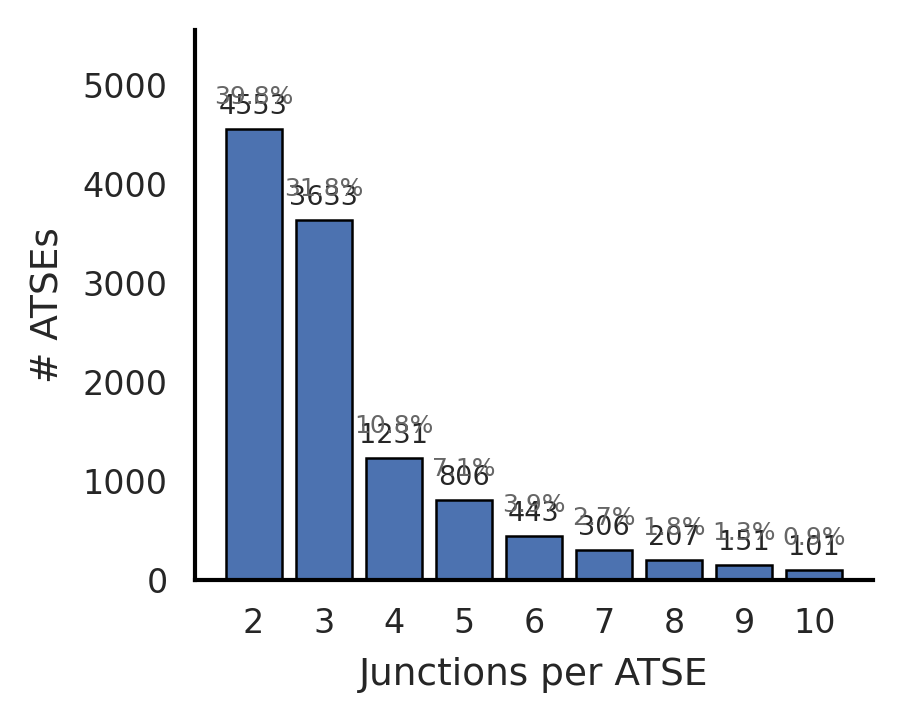

In [12]:
# ---- Compute junctions-per-ATSE ----
k_per_event = all_juncs_df.groupby("event_id")["junction_id"].nunique()
dist = k_per_event.value_counts().sort_index()
x = dist.index.to_numpy()
y = dist.to_numpy()
perc = (dist / dist.sum() * 100)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=300)
bars = ax.bar(x, y, width=0.8, edgecolor="black", linewidth=0.6)

# annotations: count (black) and percent (grey), smaller fonts
y_pad = max(1, int(y.max() * 0.02))
for xi, yi, pi in zip(x, y, perc):
    ax.text(xi, yi + y_pad, f"{yi}", ha="center", va="bottom", fontsize=6.5)
    ax.text(xi, yi + y_pad*2.2, f"{pi:.1f}%", ha="center", va="bottom",
            fontsize=6, color="0.4")  # grey

ax.set_xlabel("Junctions per ATSE", fontsize=9)
ax.set_ylabel("# ATSEs", fontsize=9)
ax.set_xticks(x)
ax.set_ylim(0, y.max() * 1.22)

# minimal styling
ax.tick_params(axis="both", labelsize=8, length=3)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# ---- Save ----
output_file = os.path.join(output_dir, "junctions_per_ATSE_barplot.pdf")
plt.savefig(output_file, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

Total genes: 5925
Total ATSEs: 11431
Mean ATSEs per gene: 1.93
Median ATSEs per gene: 2.0
Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/ATSEs_per_gene_barplot.pdf


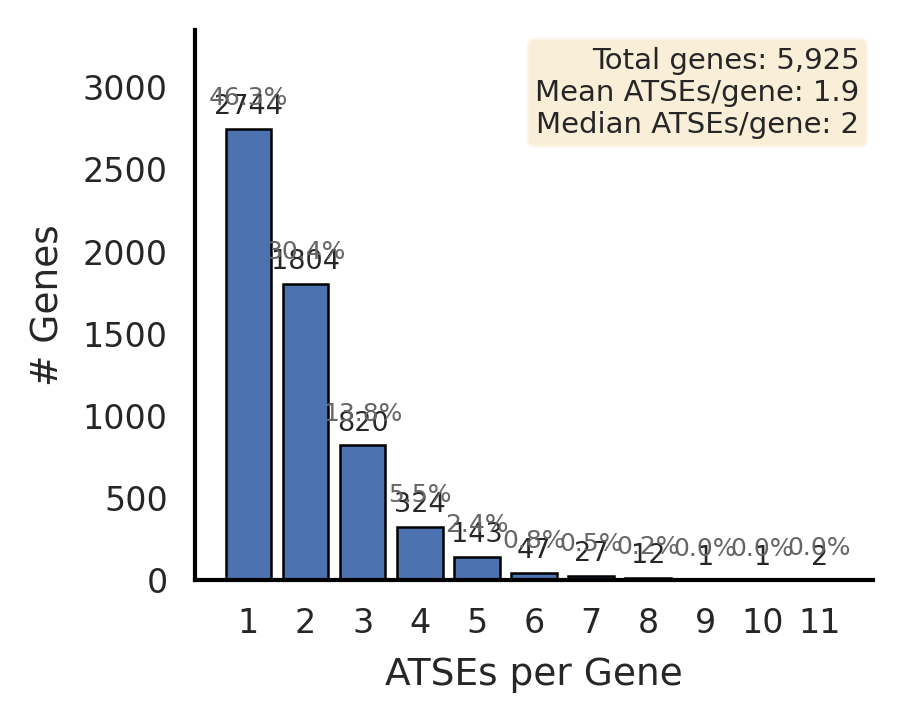


Top 10 genes with most ATSEs:
  SORBS1: 11 ATSEs
  SORBS2: 11 ATSEs
  KTN1: 10 ATSEs
  FAP: 9 ATSEs
  AKAP13: 8 ATSEs
  ATG16L2: 8 ATSEs
  CAMK2G: 8 ATSEs
  DENND1C: 8 ATSEs
  FOXP1: 8 ATSEs
  GOLGA4: 8 ATSEs


In [13]:
# ---- Compute ATSEs-per-gene ----
atses_per_gene = all_juncs_df.groupby("gene_name")["event_id"].nunique()
dist = atses_per_gene.value_counts().sort_index()
x = dist.index.to_numpy()
y = dist.to_numpy()
perc = (dist / dist.sum() * 100)

# Calculate some summary statistics
total_genes = atses_per_gene.shape[0]
total_atses = atses_per_gene.sum()
mean_atses = atses_per_gene.mean()
median_atses = atses_per_gene.median()

print(f"Total genes: {total_genes}")
print(f"Total ATSEs: {total_atses}")
print(f"Mean ATSEs per gene: {mean_atses:.2f}")
print(f"Median ATSEs per gene: {median_atses:.1f}")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=300)

# Determine binning strategy based on data range
max_atses = x.max()
if max_atses > 20:
    # Group larger values into bins for cleaner visualization
    bins = list(range(1, 21)) + [25, 30, 40, 50, 75, 100, 150, 200, max_atses+1]
    binned_counts = pd.cut(atses_per_gene, bins=bins, right=False, include_lowest=True)
    dist_binned = binned_counts.value_counts().sort_index()
    
    # Create labels for bins
    labels = []
    for interval in dist_binned.index:
        if interval.right - interval.left == 1:
            labels.append(f"{int(interval.left)}")
        elif interval.right == max_atses+1:
            labels.append(f"{int(interval.left)}+")
        else:
            labels.append(f"{int(interval.left)}-{int(interval.right-1)}")
    
    bars = ax.bar(range(len(dist_binned)), dist_binned.values, width=0.8, 
                  edgecolor="black", linewidth=0.6)
    ax.set_xticks(range(len(dist_binned)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Add annotations
    y_pad = max(1, int(dist_binned.values.max() * 0.02))
    for i, (count, pct) in enumerate(zip(dist_binned.values, dist_binned.values/dist_binned.sum()*100)):
        if count > 0:  # Only annotate non-zero bars
            ax.text(i, count + y_pad, f"{count}", ha="center", va="bottom", fontsize=6.5)
            ax.text(i, count + y_pad*2.2, f"{pct:.1f}%", ha="center", va="bottom",
                   fontsize=6, color="0.4")
    
    ax.set_ylim(0, dist_binned.values.max() * 1.22)
    
else:
    # For smaller range, plot each value individually
    bars = ax.bar(x, y, width=0.8, edgecolor="black", linewidth=0.6)
    
    # annotations: count (black) and percent (grey), smaller fonts
    y_pad = max(1, int(y.max() * 0.02))
    for xi, yi, pi in zip(x, y, perc):
        ax.text(xi, yi + y_pad, f"{yi}", ha="center", va="bottom", fontsize=6.5)
        ax.text(xi, yi + y_pad*2.2, f"{pi:.1f}%", ha="center", va="bottom",
                fontsize=6, color="0.4")
    
    ax.set_xticks(x)
    ax.set_ylim(0, y.max() * 1.22)

ax.set_xlabel("ATSEs per Gene", fontsize=9)
ax.set_ylabel("# Genes", fontsize=9)

# Add summary text box
textstr = f'Total genes: {total_genes:,}\nMean ATSEs/gene: {mean_atses:.1f}\nMedian ATSEs/gene: {median_atses:.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=7,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# minimal styling
ax.tick_params(axis="both", labelsize=8, length=3)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# ---- Save ----
output_file = os.path.join(output_dir, "ATSEs_per_gene_barplot.pdf")
plt.savefig(output_file, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

# ---- Optional: Show top genes with most ATSEs ----
top_genes = atses_per_gene.nlargest(10)
print(f"\nTop 10 genes with most ATSEs:")
for gene, n_atses in top_genes.items():
    print(f"  {gene}: {n_atses} ATSEs")

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/perplexity_cartoon_simple.pdf


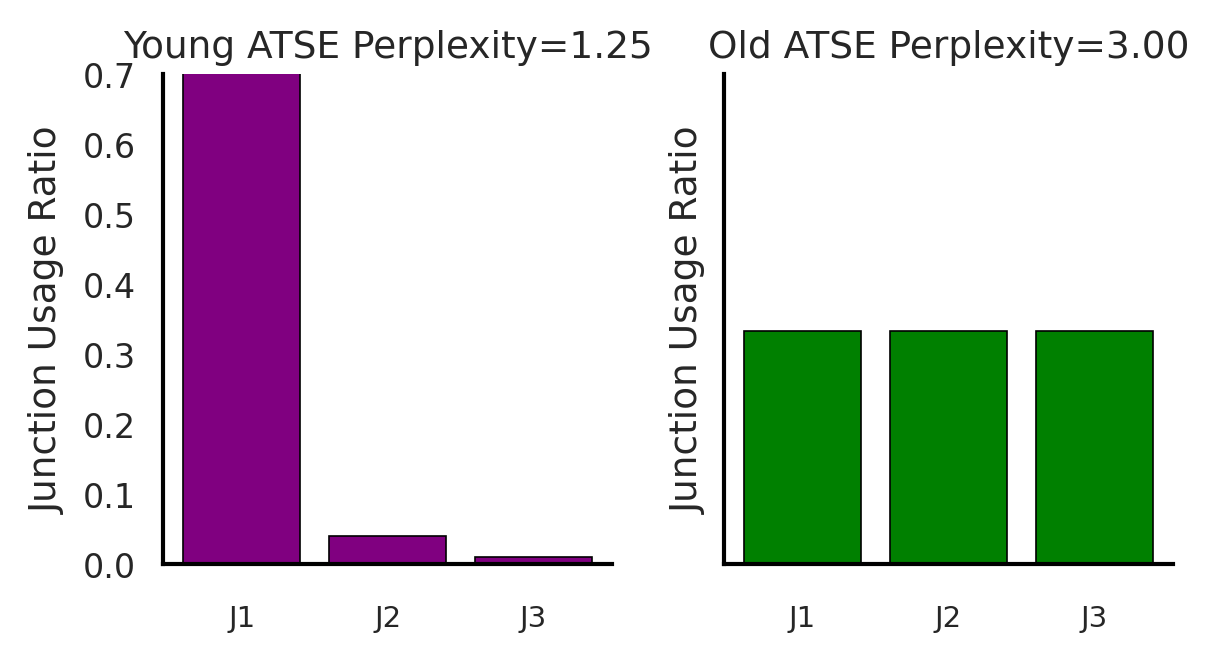

In [14]:
from scipy.stats import entropy

# --- toy PSI proportions (edit to taste) ---
young = np.array([0.95, 0.04, 0.01])          # peaked: one dominant site
old   = np.array([0.30, 0.30, 0.30])          # spread across three sites

def norm(p):
    p = np.clip(np.asarray(p, float), 0, None)
    s = p.sum()
    return p/s if s > 0 else p

def perplexity(p):
    p = norm(p)
    return float(np.exp(entropy(p)))           # natural-log entropy

Y, O = norm(young), norm(old)
PPY, PPO = perplexity(Y), perplexity(O)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(4.2, 2.4), dpi=300, sharey=True)

def bars(ax, p, title):
    x = np.arange(1, len(p)+1)
    ax.bar(x, p, width=0.8, color=("purple" if "Young" in title else "green"),
           edgecolor="black", linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"J{j}" for j in x], fontsize=7)
    ax.set_ylim(0, max(0.7, p.max()*1.15))
    ax.set_ylabel("Junction Usage Ratio", fontsize=9)
    ax.set_title(title, fontsize=9, pad=4, loc="center")
    for s in ("top","right"): ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", labelsize=8, length=3)

bars(axes[0], Y, f"Young ATSE Perplexity={PPY:.2f}")
bars(axes[1], O, f"Old ATSE Perplexity={PPO:.2f}")

plt.tight_layout()

# save (optional)
out = os.path.join(output_dir, "perplexity_cartoon_simple.pdf")
plt.savefig(out, bbox_inches="tight")
print(f"Saved plot to {out}")
plt.show()

In [15]:
all_juncs_df.sort_values(by="delta_pb", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
370099,BAT_Other immune cell,chr2_35282601_35283904_+,ENSMUSG00000026879.14_atse_1,GSN,71.0,72.0,0.347038,0.408249,0.061211,0.000000,0.0,0.000000,0.068511,0.829812,0.761301
836554,Bladder_Bladder epithelial cell,chr13_55506367_55507329_-,ENSMUSG00000021493.15_atse_3,PDLIM7,54.0,130.0,0.656751,0.920559,0.263808,1.000000,1.0,0.000000,0.201439,0.831975,0.630536
734171,Large_Intestine_Intestinal epithelial cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,176.0,477.0,0.374684,0.695425,0.320741,0.000000,1.0,1.000000,0.195542,0.751538,0.555996
149580,Brain_Non-Myeloid_Endothelial cell,chr11_109365762_109380214_+,ENSMUSG00000020611.14_atse_2,GNA13,51.0,55.0,0.500754,0.673994,0.173240,0.538462,1.0,0.461538,0.242667,0.793239,0.550572
293666,Heart_Fibroblast,chr9_108500269_108501839_+,ENSMUSG00000006676.16_atse_7,USP19,128.0,81.0,0.738475,0.851852,0.113377,1.000000,1.0,0.000000,0.334572,0.880706,0.546134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149581,Brain_Non-Myeloid_Endothelial cell,chr11_109365762_109392345_+,ENSMUSG00000020611.14_atse_2,GNA13,51.0,55.0,0.499246,0.326006,-0.173240,0.461538,0.0,-0.461538,0.757333,0.206761,-0.550572
734172,Large_Intestine_Intestinal epithelial cell,chr10_81350189_81350406_-,ENSMUSG00000020232.17_atse_1,HMG20B,176.0,477.0,0.625316,0.304575,-0.320741,1.000000,0.0,-1.000000,0.804458,0.248462,-0.555996
632321,Diaphragm_Skeletal muscle cell,chr9_7861407_7872822_-,ENSMUSG00000032000.17_atse_1,BIRC3,124.0,68.0,0.640603,0.200351,-0.440252,1.000000,0.0,-1.000000,0.715308,0.111708,-0.603600
836555,Bladder_Bladder epithelial cell,chr13_55507123_55507329_-,ENSMUSG00000021493.15_atse_3,PDLIM7,54.0,130.0,0.343249,0.079441,-0.263808,0.000000,0.0,0.000000,0.798561,0.168025,-0.630536


In [16]:
all_juncs_df[all_juncs_df["event_id"] == "ENSMUSG00000020232.17_atse_1"].sort_values(by="delta_pb", ascending=False)

,cell_type,junction_id,event_id,gene_name,n_cells_young,n_cells_old,psi_mean_young,psi_mean_old,delta_psi_mean,psi_median_young,psi_median_old,delta_psi_median,pb_young,pb_old,delta_pb
734171,Large_Intestine_Intestinal epithelial cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,176.0,477.0,0.374684,0.695425,0.320741,0.0,1.000000,1.000000,0.195542,0.751538,0.555996
491165,Bladder_Urogenital epithelial cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,83.0,132.0,0.171733,0.507672,0.335939,0.0,0.698006,0.698006,0.075829,0.540438,0.464608
148642,Brain_Non-Myeloid_Endothelial cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,67.0,121.0,0.499250,0.689216,0.189966,0.5,1.000000,0.500000,0.290234,0.726708,0.436474
972023,Large_Intestine_Epithelial stem cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,102.0,160.0,0.355678,0.539198,0.183519,0.0,0.689631,0.689631,0.199609,0.563234,0.363625
1021271,Heart_Endothelial cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,77.0,101.0,0.555288,0.613861,0.058574,1.0,1.000000,0.000000,0.347921,0.685106,0.337185
684900,Large_Intestine_Specialized intestinal cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,133.0,167.0,0.311681,0.470960,0.159279,0.0,0.222222,0.222222,0.169620,0.501548,0.331928
921308,GAT_Mesenchymal stem cell,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,101.0,120.0,0.165677,0.308527,0.142850,0.0,0.000000,0.000000,0.059829,0.332066,0.272237
248466,Heart_Fibroblast,chr10_81350189_81350272_-,ENSMUSG00000020232.17_atse_1,HMG20B,179.0,117.0,0.231650,0.318396,0.086746,0.0,0.000000,0.000000,0.067150,0.273241,0.206091
248467,Heart_Fibroblast,chr10_81350189_81350406_-,ENSMUSG00000020232.17_atse_1,HMG20B,179.0,117.0,0.768350,0.681604,-0.086746,1.0,1.000000,0.000000,0.932850,0.726759,-0.206091
921309,GAT_Mesenchymal stem cell,chr10_81350189_81350406_-,ENSMUSG00000020232.17_atse_1,HMG20B,101.0,120.0,0.834323,0.691473,-0.142850,1.0,1.000000,0.000000,0.940171,0.667934,-0.272237



HMG20B - Large_Intestine_Intestinal epithelial cell

Sample counts per junction and age group:
cell_age_group             old  young
junction_id                          
chr10_81350189_81350272_-  477    176
chr10_81350189_81350406_-  477    176

PseudoBulk PSI vs Mean Single Cell PSI comparison:
                 junction_id cell_age_group  pseudobulk_psi  mean_sc_psi  \
0  chr10_81350189_81350272_-            old          0.7515       0.6954   
1  chr10_81350189_81350272_-          young          0.1955       0.3747   
2  chr10_81350189_81350406_-            old          0.2485       0.3046   
3  chr10_81350189_81350406_-          young          0.8045       0.6253   

   difference  
0      0.0561  
1     -0.1791  
2     -0.0561  
3      0.1791  


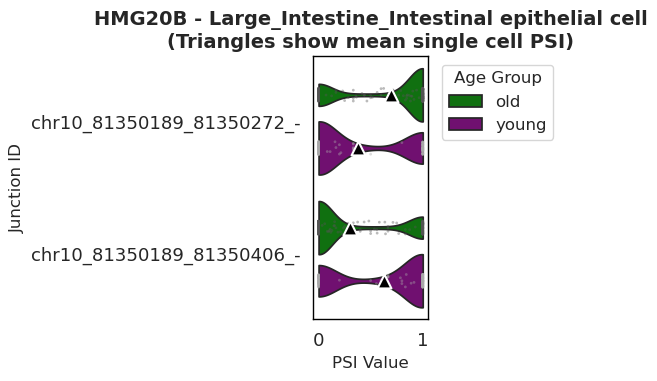

                                    cell_type                junction_id  \
0  Large_Intestine_Intestinal epithelial cell  chr10_81350189_81350272_-   
1  Large_Intestine_Intestinal epithelial cell  chr10_81350189_81350406_-   

                       event_id gene_name  n_cells_young  n_cells_old  \
0  ENSMUSG00000020232.17_atse_1    HMG20B            176          477   
1  ENSMUSG00000020232.17_atse_1    HMG20B            176          477   

   psi_mean_young  psi_mean_old  delta_psi_mean  psi_median_young  \
0        0.374684      0.695425        0.320741               0.0   
1        0.625316      0.304575       -0.320741               1.0   

   psi_median_old  delta_psi_median  pb_young    pb_old  delta_pb  
0             1.0               1.0  0.195542  0.751538  0.555996  
1             0.0              -1.0  0.804458  0.248462 -0.555996  
                                    cell_type                      event_id  \
0  Large_Intestine_Intestinal epithelial cell  ENSMUSG000000

In [17]:
junction ="chr10_81350189_81350272_-"
cell_type = "Large_Intestine_Intestinal epithelial cell"
result_df  = extract_junction_data(splice_adata, junction, cell_type)
j_df, atse_df = delta_psi_from_result_df(result_df)
plot_junction_usage_by_age(result_df, output_dir)
print(j_df)
print(atse_df)


HMG20B - Brain_Non-Myeloid_Endothelial cell

Sample counts per junction and age group:
cell_age_group             old  young
junction_id                          
chr10_81350189_81350272_-  121     67
chr10_81350189_81350406_-  121     67

PseudoBulk PSI vs Mean Single Cell PSI comparison:
                 junction_id cell_age_group  pseudobulk_psi  mean_sc_psi  \
0  chr10_81350189_81350272_-            old          0.7267       0.6892   
1  chr10_81350189_81350272_-          young          0.2902       0.4992   
2  chr10_81350189_81350406_-            old          0.2733       0.3108   
3  chr10_81350189_81350406_-          young          0.7098       0.5008   

   difference  
0      0.0375  
1     -0.2090  
2     -0.0375  
3      0.2090  


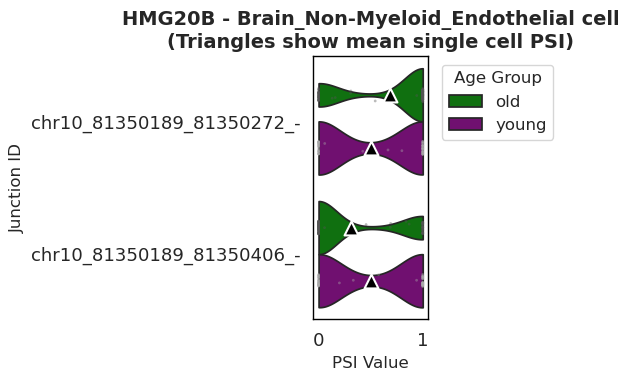

                            cell_type                junction_id  \
0  Brain_Non-Myeloid_Endothelial cell  chr10_81350189_81350272_-   
1  Brain_Non-Myeloid_Endothelial cell  chr10_81350189_81350406_-   

                       event_id gene_name  n_cells_young  n_cells_old  \
0  ENSMUSG00000020232.17_atse_1    HMG20B             67          121   
1  ENSMUSG00000020232.17_atse_1    HMG20B             67          121   

   psi_mean_young  psi_mean_old  delta_psi_mean  psi_median_young  \
0         0.49925      0.689216        0.189966               0.5   
1         0.50075      0.310784       -0.189966               0.5   

   psi_median_old  delta_psi_median  pb_young    pb_old  delta_pb  
0             1.0               0.5  0.290234  0.726708  0.436474  
1             0.0              -0.5  0.709766  0.273292 -0.436474  
                            cell_type                      event_id  \
0  Brain_Non-Myeloid_Endothelial cell  ENSMUSG00000020232.17_atse_1   

   n_junctions  mean

In [18]:
cell_type = "Brain_Non-Myeloid_Endothelial cell"
result_df  = extract_junction_data(splice_adata, junction, cell_type)
j_df, atse_df = delta_psi_from_result_df(result_df)
plot_junction_usage_by_age(result_df, output_dir)
print(j_df)
print(atse_df)

Unique transcripts: {'ENSMUST00000105323.7', 'ENSMUST00000105324.8', 's2f37a80fa1ea3849:e6d94b8027b8cf1a0', 'sa87494ddc3b1a009:ef91091ecf6872e6c', 's98a3fee059c3114d:e4bcc4490f9da43b2', 'sf7bbc495fdce7f50:e900b6205e7a5600d', 'sfc15eee5f534f19a:e8281372ed8806996', 'sf73b299af1e5a4a8:e2427d34fa1274cf9', 'sae4d0842454ae0ac:ead1e3e9c006d6770', 's962c3eb79662b5d1:ead1e3e9c006d6770', 's9f84a80ccef327ee:ead1e3e9c006d6770', 's48aa351b76fc664b:e8281372ed8806996', 'sf73b299af1e5a4a8:ef91091ecf6872e6c', 'sa87494ddc3b1a009:eb613fe4b59c174e6', 'sa80a7d0338135272:e6d94b8027b8cf1a0'}
Unique transcripts: ['ENSMUST00000105323.7', 'ENSMUST00000105324.8']
Unique transcripts to remove: ['s2f37a80fa1ea3849:e6d94b8027b8cf1a0', 's48aa351b76fc664b:e8281372ed8806996', 's962c3eb79662b5d1:ead1e3e9c006d6770', 's98a3fee059c3114d:e4bcc4490f9da43b2', 's9f84a80ccef327ee:ead1e3e9c006d6770', 'sa80a7d0338135272:e6d94b8027b8cf1a0', 'sa87494ddc3b1a009:eb613fe4b59c174e6', 'sa87494ddc3b1a009:ef91091ecf6872e6c', 'sae4d084245

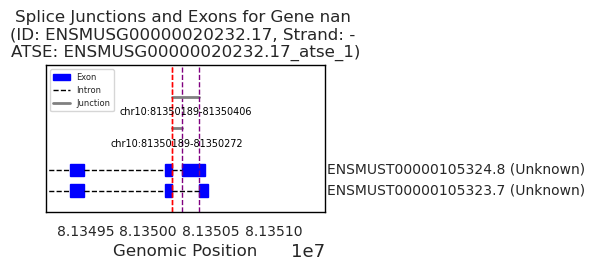

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/200805_mouse_nan_ENSMUSG00000020232.17_atse_1.pdf


{'junctions':                           event_id                gene_id  gene_name  \
 3076  ENSMUSG00000020232.17_atse_1  ENSMUSG00000020232.17        NaN   
 3077  ENSMUSG00000020232.17_atse_1  ENSMUSG00000020232.17        NaN   
 
       gene_types  num_junctions           event_type chromosome strand  \
 3076         NaN              2  alternative_5_prime      chr10      -   
 3077         NaN              2  alternative_5_prime      chr10      -   
 
       atse_start  atse_end  ...  acceptor_usage  donor_total_reads  \
 3076    81350189  81350406  ...          1.0000             215186   
 3077    81350189  81350406  ...          0.6939             149311   
 
       acceptor_total_reads  splice_motif  donor_seq  acceptor_seq  \
 3076                 65875         GT-AG         GT            AG   
 3077                215186         GT-AG         GT            AG   
 
      position_off_5_prime position_off_3_prime usage_ratio  \
 3076                  1.0                  0.0  

In [19]:
mouse_event = "ENSMUSG00000020232.17_atse_1"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, full_atse_map, db_mouse,
                 species="mouse", base_width=6, 
                       trans_height=0.9, output_dir=output_dir,
                  padding=5, show_junc_lines=True, filter_ensembl_transcripts=True)

Figure saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/psi_young_vs_old_hexbin.pdf


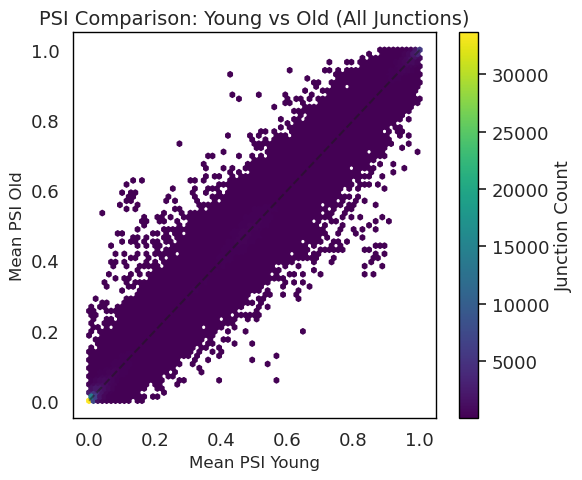

In [20]:
from scipy.stats import gaussian_kde

# Create figure with single hexbin plot
fig, ax = plt.subplots(figsize=(6, 5))

# Hexbin plot for all junctions
hb = ax.hexbin(all_juncs_df['psi_mean_young'], 
               all_juncs_df['psi_mean_old'], 
               gridsize=75, cmap='viridis', mincnt=1)

# Add diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')

# Labels and formatting
ax.set_xlabel('Mean PSI Young', fontsize=12)
ax.set_ylabel('Mean PSI Old', fontsize=12)
ax.set_title('PSI Comparison: Young vs Old (All Junctions)', fontsize=14)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Add colorbar
plt.colorbar(hb, ax=ax, label='Junction Count')
plt.tight_layout()

# Save as PDF
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "psi_young_vs_old_hexbin.pdf")
plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_file}")

plt.show()

### Barplot summarizing how often a given junction had high delta psi across cell types

Figure saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/junction_categories_across_celltypes.pdf


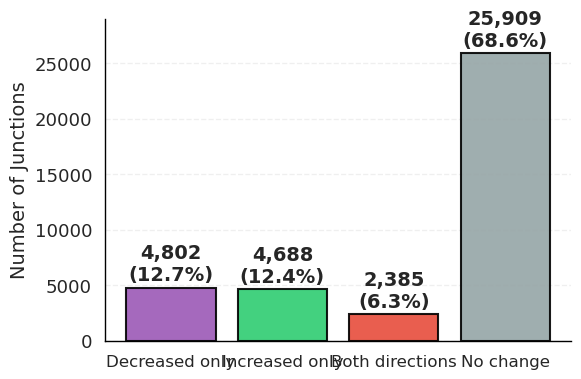


Detailed Statistics:
Total unique junctions analyzed: 37,784
Number of cell types: 27

Junction categories:
  Decreased only      :    4,802 ( 12.7%)
  Increased only      :    4,688 ( 12.4%)
  Both directions     :    2,385 (  6.3%)
  No change           :   25,909 ( 68.6%)


In [21]:
# Categorize each junction across all cell types
def categorize_junction_across_celltypes(junction_df):
    """Categorize a junction based on its behavior across all cell types"""
    increased_in_any = (junction_df['delta_psi_mean'] > 0.05).any()
    decreased_in_any = (junction_df['delta_psi_mean'] < -0.05).any()
    
    if increased_in_any and decreased_in_any:
        return 'Both directions'
    elif increased_in_any:
        return 'Increased only'
    elif decreased_in_any:
        return 'Decreased only'
    else:
        return 'No change'

# Group by junction_id and categorize across all cell types
junction_categories_global = all_juncs_df.groupby('junction_id').apply(categorize_junction_across_celltypes)
junction_categories_global = junction_categories_global.reset_index()
junction_categories_global.columns = ['junction_id', 'category']

# Count junctions in each category
category_counts = junction_categories_global['category'].value_counts()
category_percentages = (category_counts / len(junction_categories_global) * 100).round(1)

# Create single figure
fig, ax = plt.subplots(figsize=(6, 4))

# Define colors
colors = {
    'Increased only': '#2ecc71',  # Green
    'Decreased only': '#9b59b6',  # Purple
    'Both directions': '#e74c3c',  # Red
    'No change': '#95a5a6'  # Gray
}

# Bar plot of categories
category_order = ['Decreased only', 'Increased only', 'Both directions', 'No change']
counts_ordered = [category_counts.get(cat, 0) for cat in category_order]
colors_ordered = [colors[cat] for cat in category_order]

bars = ax.bar(range(len(category_order)), counts_ordered, color=colors_ordered, 
               alpha=0.9, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels(category_order, fontsize=12)
ax.set_ylabel('Number of Junctions', fontsize=14)

# Add value labels on bars with larger font
for i, (bar, count) in enumerate(zip(bars, counts_ordered)):
    percentage = category_percentages.get(category_order[i], 0)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_ordered)*0.01,
            f'{count:,}\n({percentage}%)', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

ax.set_ylim(0, max(counts_ordered) * 1.12)

# Add grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save as PDF
output_file = os.path.join(output_dir, "junction_categories_across_celltypes.pdf")
plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_file}")
plt.show()

# Detailed analysis with top junctions per category
print("\nDetailed Statistics:")
print("="*80)
print(f"Total unique junctions analyzed: {len(junction_categories_global):,}")
print(f"Number of cell types: {all_juncs_df['cell_type'].nunique()}")
print("\nJunction categories:")
for cat in category_order:
    count = category_counts.get(cat, 0)
    pct = category_percentages.get(cat, 0)
    print(f"  {cat:20s}: {count:8,} ({pct:5.1f}%)")

In [33]:
4802+4688+2385

11875

### Calculate ATSE perplexity in every cell that has ATSE detection 

In [22]:
from scipy.stats import entropy

def calculate_perplexity(psi_values):
    """
    Calculate perplexity from PSI values.
    Perplexity = exp(entropy) where entropy is calculated from PSI distribution
    """
    # Remove NaN values
    psi_values = psi_values.dropna()
    
    if len(psi_values) == 0:
        return np.nan
    
    # PSI values are already between 0-1, treat them as probabilities
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    psi_values = np.clip(psi_values, epsilon, 1-epsilon)
    
    # Normalize to ensure they sum to 1 (treating as probability distribution)
    psi_norm = psi_values / psi_values.sum()
    
    # Calculate entropy
    ent = entropy(psi_norm)
    
    # Calculate perplexity
    perp = np.exp(ent)
    
    return perp

# Calculate perplexity for each event_id in each cell type for both young and old
perplexity_results = []

for cell_type in all_juncs_df['cell_type'].unique():
    cell_data = all_juncs_df[all_juncs_df['cell_type'] == cell_type]
    
    for event_id in cell_data['event_id'].unique():
        event_data = cell_data[cell_data['event_id'] == event_id]
        
        # Get gene name for this event
        gene_name = event_data['gene_name'].iloc[0]
        
        # Calculate perplexity for young and old
        perp_young = calculate_perplexity(event_data['psi_mean_young'])
        perp_old = calculate_perplexity(event_data['psi_mean_old'])
        
        # Calculate change in perplexity
        delta_perp = perp_old - perp_young if not np.isnan(perp_young) and not np.isnan(perp_old) else np.nan
        
        perplexity_results.append({
            'cell_type': cell_type,
            'event_id': event_id,
            'gene_name': gene_name,
            'n_junctions': len(event_data),
            'perplexity_young': perp_young,
            'perplexity_old': perp_old,
            'delta_perplexity': delta_perp
        })

# Convert to DataFrame
perplexity_df = pd.DataFrame(perplexity_results)

# Filter out events with only 1 junction (perplexity not meaningful)
perplexity_df_filtered = perplexity_df[perplexity_df['n_junctions'] > 1].copy()

Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/perplexity_violin_plot.pdf


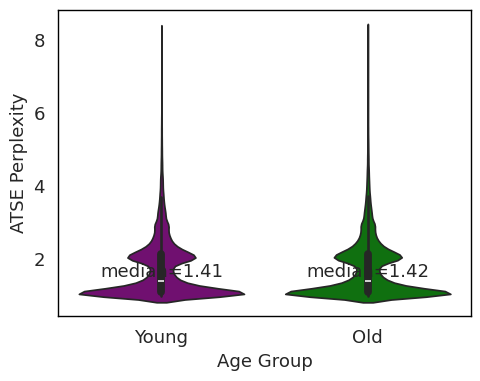

In [23]:
# Create violin plot using seaborn
plt.figure(figsize=(5, 4))
sns.violinplot(data=[perplexity_df_filtered['perplexity_young'], 
                    perplexity_df_filtered['perplexity_old']], 
               palette=['purple', 'green'])

# Update x-axis labels
plt.xticks([0, 1], ['Young', 'Old'])

# Add median value text annotations
young_median = perplexity_df_filtered['perplexity_young'].median()
old_median = perplexity_df_filtered['perplexity_old'].median()
plt.text(0, young_median, f'median={young_median:.2f}', ha='center', va='bottom')
plt.text(1, old_median, f'median={old_median:.2f}', ha='center', va='bottom')

plt.xlabel('Age Group')
plt.ylabel('ATSE Perplexity')
plt.tight_layout()

# Save plot
output_file = os.path.join(output_dir, "perplexity_violin_plot.pdf")
plt.savefig(output_file, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

### Panels G-I: pairwise PSI correlation across cell types in younger cells versus older cells

In [24]:
# Filter splice_adata to junctions in twos_all_juncs
junctions_to_use = twos_all_juncs["junction_id"].unique()
# splice_adata_filt = splice_adata[:, splice_adata.var["junction_id"].isin(junctions_to_use)]

# Get cell types from twos_all_juncs
cell_types_to_use = twos_all_juncs["cell_type"].unique()
splice_adata_filt = splice_adata[splice_adata.obs["tissue_celltype"].isin(cell_types_to_use)]

def calculate_correlations(adata, age_group):
    """Calculate pairwise correlations for a specific age group"""
    adata_age = adata[adata.obs["age_group"] == age_group]
    
    cell_types = adata_age.obs["tissue_celltype"].values
    unique_celltypes = np.unique(cell_types)
    
    psi_matrix = adata_age.layers["psi"]
    psi_by_celltype = []
    
    for ct in unique_celltypes:
        mask = cell_types == ct
        ct_mean = np.array(psi_matrix[mask, :].mean(axis=0)).flatten()
        psi_by_celltype.append(ct_mean)
    
    psi_by_celltype = pd.DataFrame(
        psi_by_celltype,
        index=unique_celltypes,
        columns=adata_age.var["junction_id"].values
    )
    
    return psi_by_celltype.T.corr()

# Calculate correlations for young and old
corr_young = calculate_correlations(splice_adata, "young")
corr_old = calculate_correlations(splice_adata, "old")

# Calculate delta (change in correlation from young to old)
delta_corr = corr_old - corr_young

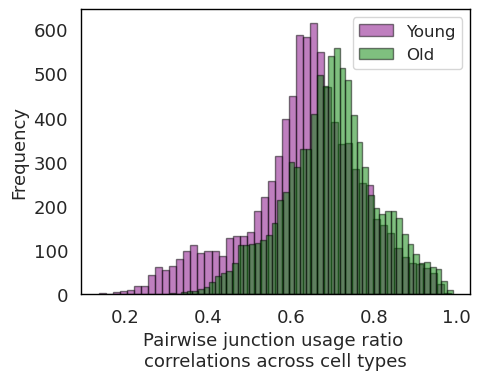

In [25]:
# Get upper triangle values for young and old correlations separately
upper_triangle_mask = np.triu(np.ones_like(corr_young, dtype=bool), k=1)
young_values = corr_young.where(upper_triangle_mask).stack()
old_triangle_mask = np.triu(np.ones_like(corr_old, dtype=bool), k=1)
old_values = corr_old.where(old_triangle_mask).stack()

# Plot histograms
plt.figure(figsize=(5, 4))
plt.hist(young_values, bins=50, alpha=0.5, label='Young', color='purple', edgecolor='black')
plt.hist(old_values, bins=50, alpha=0.5, label='Old', color='green', edgecolor='black')
plt.xlabel('Pairwise junction usage ratio \ncorrelations across cell types')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_distributions.pdf'))

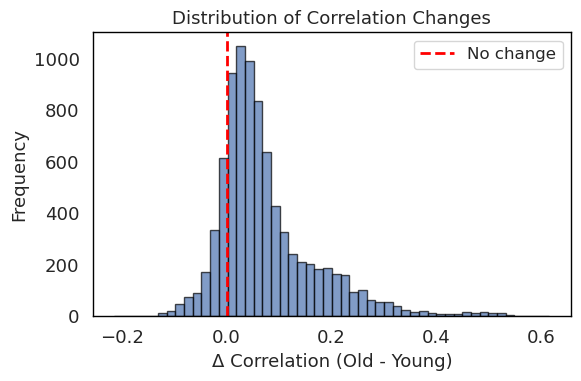

In [26]:
# Get upper triangle (to avoid counting each pair twice)
upper_triangle_mask = np.triu(np.ones_like(delta_corr, dtype=bool), k=1)
delta_values = delta_corr.where(upper_triangle_mask).stack()

# Visualization
plt.figure(figsize=(6, 4))
plt.hist(delta_values, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Δ Correlation (Old - Young)')
plt.ylabel('Frequency')
plt.title('Distribution of Correlation Changes')
plt.legend()
plt.tight_layout()
plt.show()

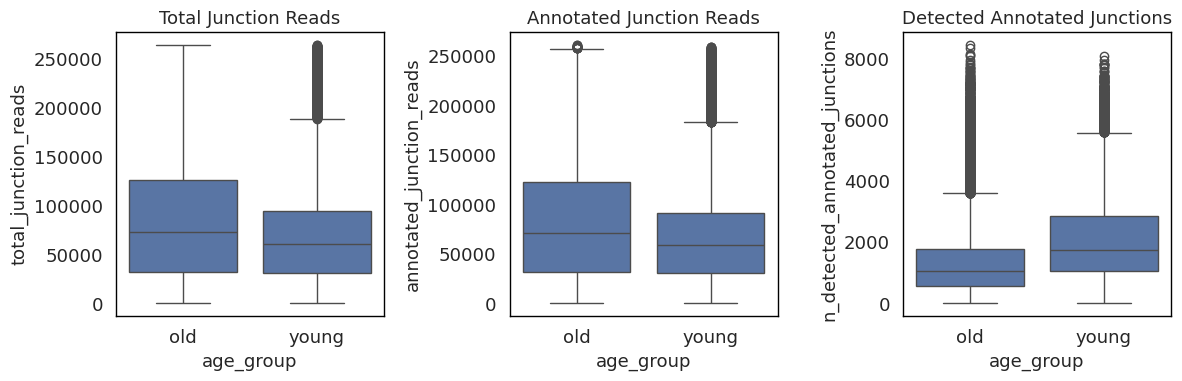

In [27]:
# make boxplot comparing splice_adata.obs total_junction_reads, annotated_junction_reads, n_detected_annotated_junctions broken down by age_group 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Boxplot for total_junction_reads
sns.boxplot(x="age_group", y="total_junction_reads", data=splice_adata.obs, ax=axes[0])
axes[0].set_title('Total Junction Reads')

# Boxplot for annotated_junction_reads
sns.boxplot(x="age_group", y="annotated_junction_reads", data=splice_adata.obs, ax=axes[1])
axes[1].set_title('Annotated Junction Reads')

# Boxplot for n_detected_annotated_junctions
sns.boxplot(x="age_group", y="n_detected_annotated_junctions", data=splice_adata.obs, ax=axes[2])
axes[2].set_title('Detected Annotated Junctions')

plt.tight_layout()
plt.show()

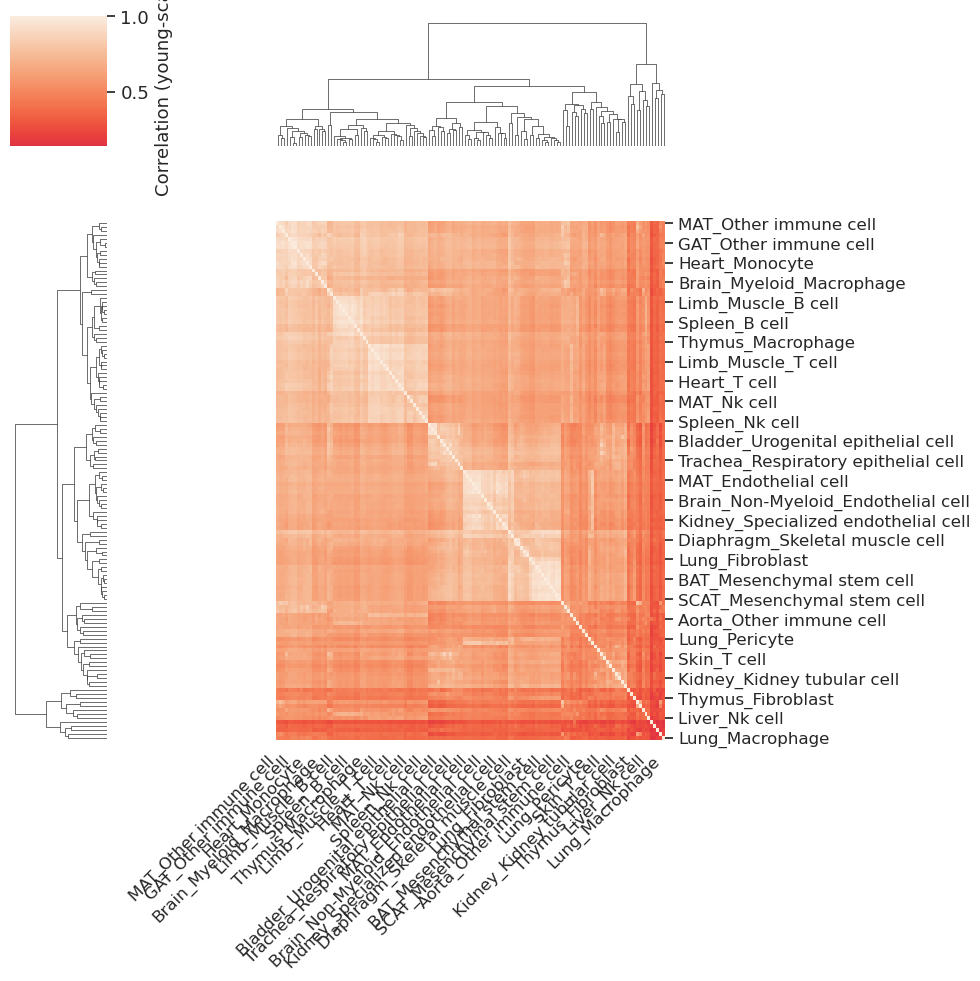

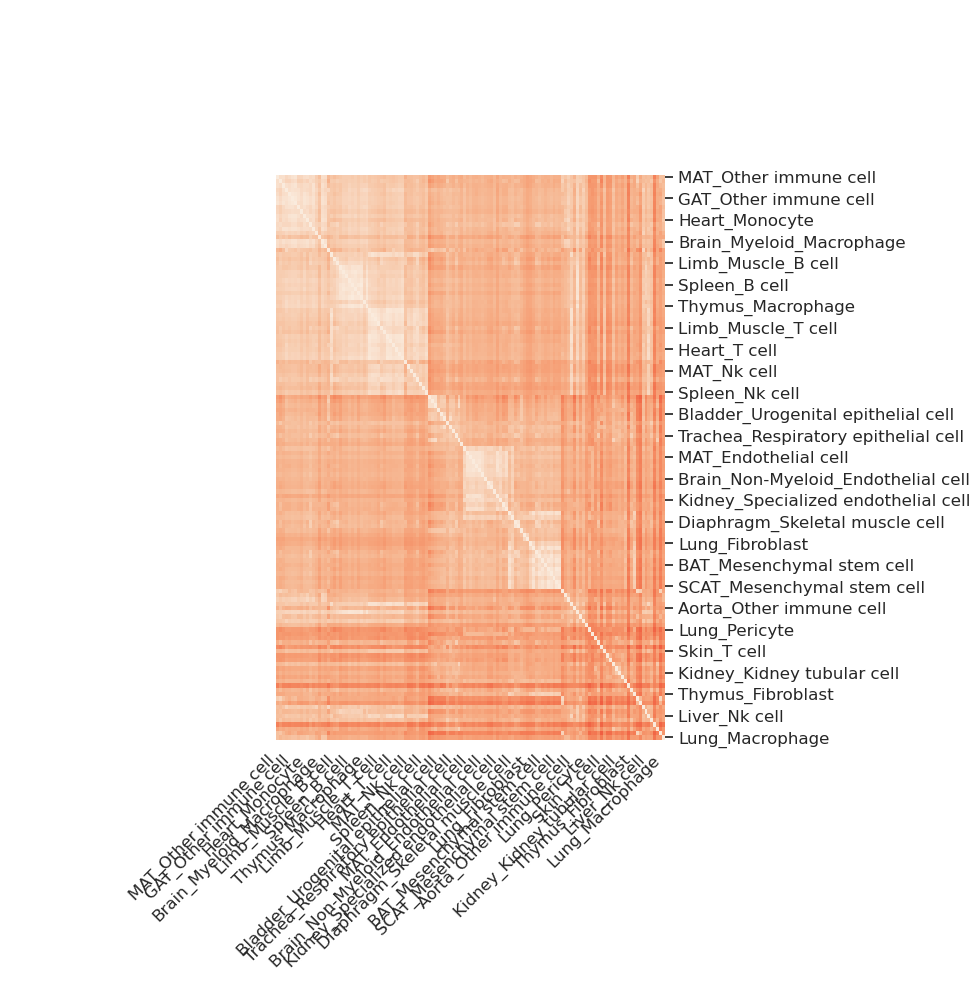

In [28]:
# IMPROVED VERSION: Align on common labels with better formatting
common = corr_young.index.intersection(corr_old.index)
cY = corr_young.loc[common, common]
cO = corr_old.loc[common, common]

# vmin from young (ignore diagonal 1.0s), vmax fixed to 1.0
arr = cY.to_numpy().copy()
np.fill_diagonal(arr, np.nan)
vmin = np.nanmin(arr)
vmax = 1.0

# 1) Cluster YOUNG (this defines the order)
g = sns.clustermap(
    cY, row_cluster=True, col_cluster=True,
    cmap="rocket", center=0, vmin=vmin, vmax=vmax,
    cbar_kws={"label": "Correlation (young-scale)"}
)

# Improve formatting: reduce font size and rotate column labels
g.ax_heatmap.tick_params(axis='both', which='major', labelsize=12)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)

# Save young correlation plot as PDF
plt.tight_layout()
g.savefig(os.path.join(output_dir, 'young_correlation_clustermap.pdf'), dpi=300, bbox_inches='tight')
plt.show()

row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
ordered_idx = cY.index.to_numpy()[row_order]
ordered_col = cY.columns.to_numpy()[col_order]

# 2) Reindex OLD and plot with SAME color scale; hide its colorbar
cO_ordered = cO.loc[ordered_idx, ordered_col]
g_old = sns.clustermap(
    cO_ordered, row_cluster=False, col_cluster=False,
    cmap="rocket", center=0, vmin=vmin, vmax=vmax,
    cbar_pos=None
)

# Improve formatting for old correlation plot: reduce font size and rotate column labels
g_old.ax_heatmap.tick_params(axis='both', which='major', labelsize=12)
g_old.ax_heatmap.set_xticklabels(g_old.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g_old.ax_heatmap.set_yticklabels(g_old.ax_heatmap.get_yticklabels(), rotation=0)

# Save old correlation plot as PDF
plt.tight_layout()
g_old.savefig(os.path.join(output_dir, 'old_correlation_clustermap.pdf'), dpi=300, bbox_inches='tight')
plt.show()


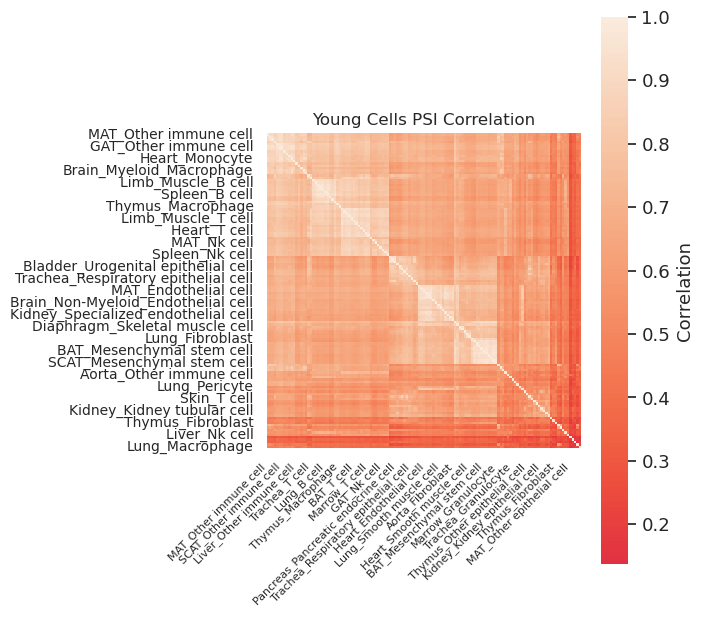

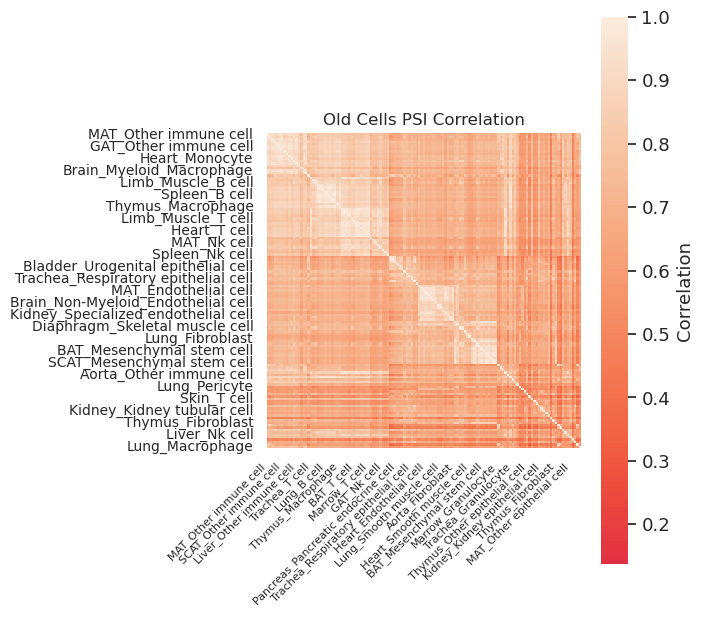

In [29]:
# IMPROVED VERSION: Align on common labels with better formatting
common = corr_young.index.intersection(corr_old.index)
cY = corr_young.loc[common, common]
cO = corr_old.loc[common, common]

# vmin from young (ignore diagonal 1.0s), vmax fixed to 1.0
arr = cY.to_numpy().copy()
np.fill_diagonal(arr, np.nan)
vmin = np.nanmin(arr)
vmax = 1.0

# 1) Get clustering order from clustermap but don't display it
g_temp = sns.clustermap(
    cY, row_cluster=True, col_cluster=True,
    cmap="rocket", center=0, vmin=vmin, vmax=vmax,
)
row_order = g_temp.dendrogram_row.reordered_ind
col_order = g_temp.dendrogram_col.reordered_ind
plt.close()  # Close the temporary figure

# Get ordered data
ordered_idx = cY.index.to_numpy()[row_order]
ordered_col = cY.columns.to_numpy()[col_order]
cY_ordered = cY.loc[ordered_idx, ordered_col]
cO_ordered = cO.loc[ordered_idx, ordered_col]

# Create figures with same size
fig_size = (7, 7)  # Adjust as needed

# Plot YOUNG correlation (clustered order)
fig, ax = plt.subplots(figsize=fig_size)
sns.heatmap(
    cY_ordered, 
    cmap="rocket", center=0, vmin=vmin, vmax=vmax,
    cbar_kws={"label": "Correlation"},
    ax=ax, square=True
)

# Set tick label sizes
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)  # Keep row labels at 12

# Reduce y-axis label font size (the "ylabel" if you have one)
ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Smaller font for y-axis label
ax.set_xlabel(ax.get_xlabel(), fontsize=8)  # Optional: also reduce x-axis label

ax.set_title("Young Cells PSI Correlation", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'young_correlation_heatmap.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Plot OLD correlation (same order as young)
fig, ax = plt.subplots(figsize=fig_size)
sns.heatmap(
    cO_ordered, 
    cmap="rocket", center=0, vmin=vmin, vmax=vmax,
    cbar_kws={"label": "Correlation"},
    ax=ax, square=True
)

# Set tick label sizes
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)  # Keep row labels at 12

# Reduce y-axis label font size
ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Smaller font for y-axis label
ax.set_xlabel(ax.get_xlabel(), fontsize=8)  # Optional: also reduce x-axis label

ax.set_title("Old Cells PSI Correlation", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'old_correlation_heatmap.pdf'), dpi=300, bbox_inches='tight')
plt.show()